In [7]:
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
from tqdm import tqdm
from augmentation import augments
from models import models
from dataset import train_csv_path, train_img_folder_path
from validation import k_fold_validation
import pandas as pd
from stats import mean, std


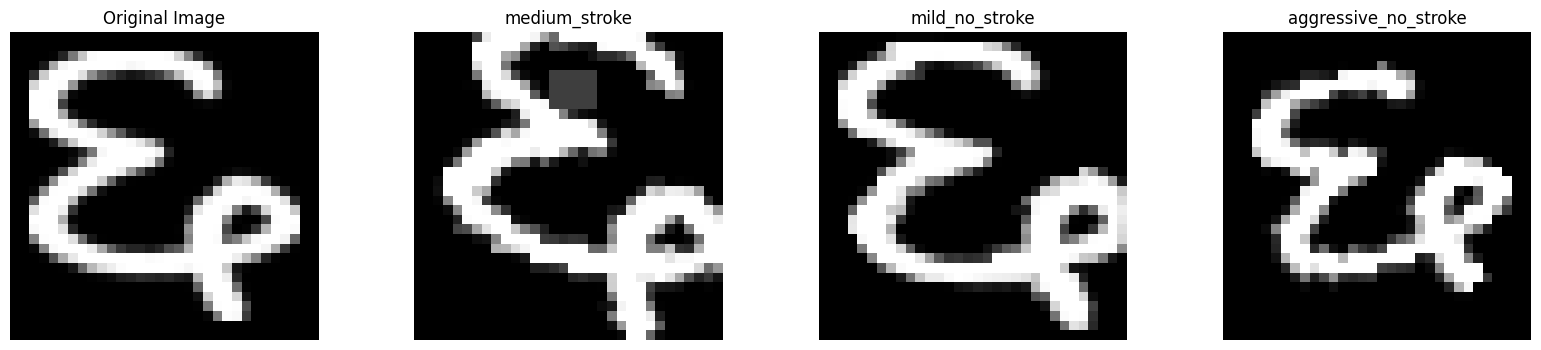

In [8]:
# HERE WE VISUALIZE AN ARBITRARY IMAGE WITH A FEW AUGMENTS
selected_augments = ['medium_stroke', 'mild_no_stroke', 'aggressive_no_stroke']


df_train = pd.read_csv(train_csv_path)
row = df_train.iloc[0]
fig, axes = plt.subplots(1, len(selected_augments)+1, figsize=(20, 4))
img = Image.open(f"{train_img_folder_path}/{int(row['Category'])}/{int(row['Id'])}.png")

axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

for i, augment_name in enumerate(selected_augments):
    transform = augments.get(augment_name)
    augmented_img = transform(img)
    tensor = augmented_img * std + mean
    tensor = tensor.clamp(0, 1)
    axes[i+1].imshow(tensor.squeeze(0), cmap='gray')
    axes[i+1].set_title(augment_name)
    axes[i+1].axis('off')

In [12]:

selected_augments = ['medium_stroke', 'mild_no_stroke', 'aggressive_no_stroke']
selected_models = ['scnn_dilated']

accuracies = {}
missed = {}


for a in selected_augments:
    m_fn = [models[m] for m in selected_models]
    a_fn = augments[a]
    acc, df_missed = k_fold_validation(df_train, augm_fn=a_fn, model_fns=m_fn, use_tta=False, k_folds=4, epochs=20, batch_size=128)
    mean = np.mean(acc)
    std = np.std(acc)
    name_mix = f"AUGMENTATION: {a}"
    print(f"{name_mix} results: mean = {mean} , std = {std}")
    accuracies[name_mix] = f"Mean = {str(mean)}, STD = {str(std)}"
    missed[name_mix] = df_missed

#a, b = k_fold_validation(df_train,
#k_fold_validation(df: pd.DataFrame, model_fns, augm_fn, use_tta=False, k_folds=4, epochs=10, batch_size=128, lr=0.01)

Fold 1/4


Epoch 3:  83%|████████▎ | 83/100 [00:45<00:09,  1.81it/s]


KeyboardInterrupt: 